# Memory Experiment — Surface Code Family

Rotated Surface Code, Unrotated Surface Code, and Toric Code.  
Each section: build a memory circuit, inspect the Stim circuit, and visualize detector slices.

In [17]:
import sys
from pathlib import Path
import numpy as np

ROOT = Path("../..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lightstim.ir.qec_system import QECSystem
from lightstim.protocols.memory import MemoryExperiment
from lightstim.qec_code.surface_code.rotated import RotatedSurfaceCode, RotatedSurfaceCodeExtractionBlock
from lightstim.qec_code.surface_code.unrotated import UnrotatedSurfaceCode, UnrotatedSurfaceCodeExtractionBlock
from lightstim.qec_code.surface_code.toric import ToricCode, ToricCodeExtractionBlock


In [18]:
from lightstim.noise.config import NoiseConfig

p = 1e-3
noise_params = NoiseConfig(p_idle=p, p_1q=p, p_2q=p, p_meas=p, p_reset=p)


## 1. Rotated Surface Code

In [19]:
d = 3
code = RotatedSurfaceCode(distance=d)
system = QECSystem()
system.add_patch(code, name="rotated_sc")

exp = MemoryExperiment(
    qec_system=system,
    extraction_block_class=RotatedSurfaceCodeExtractionBlock,
    rounds=d,
    noise_params=noise_params,
    noise_model="circuit_level",
    basis="Z", # Z or X
)
circuit_rotated = exp.build()
print(f"Qubits: {circuit_rotated.num_qubits}  Detectors: {circuit_rotated.num_detectors}")

Qubits: 17  Detectors: 24


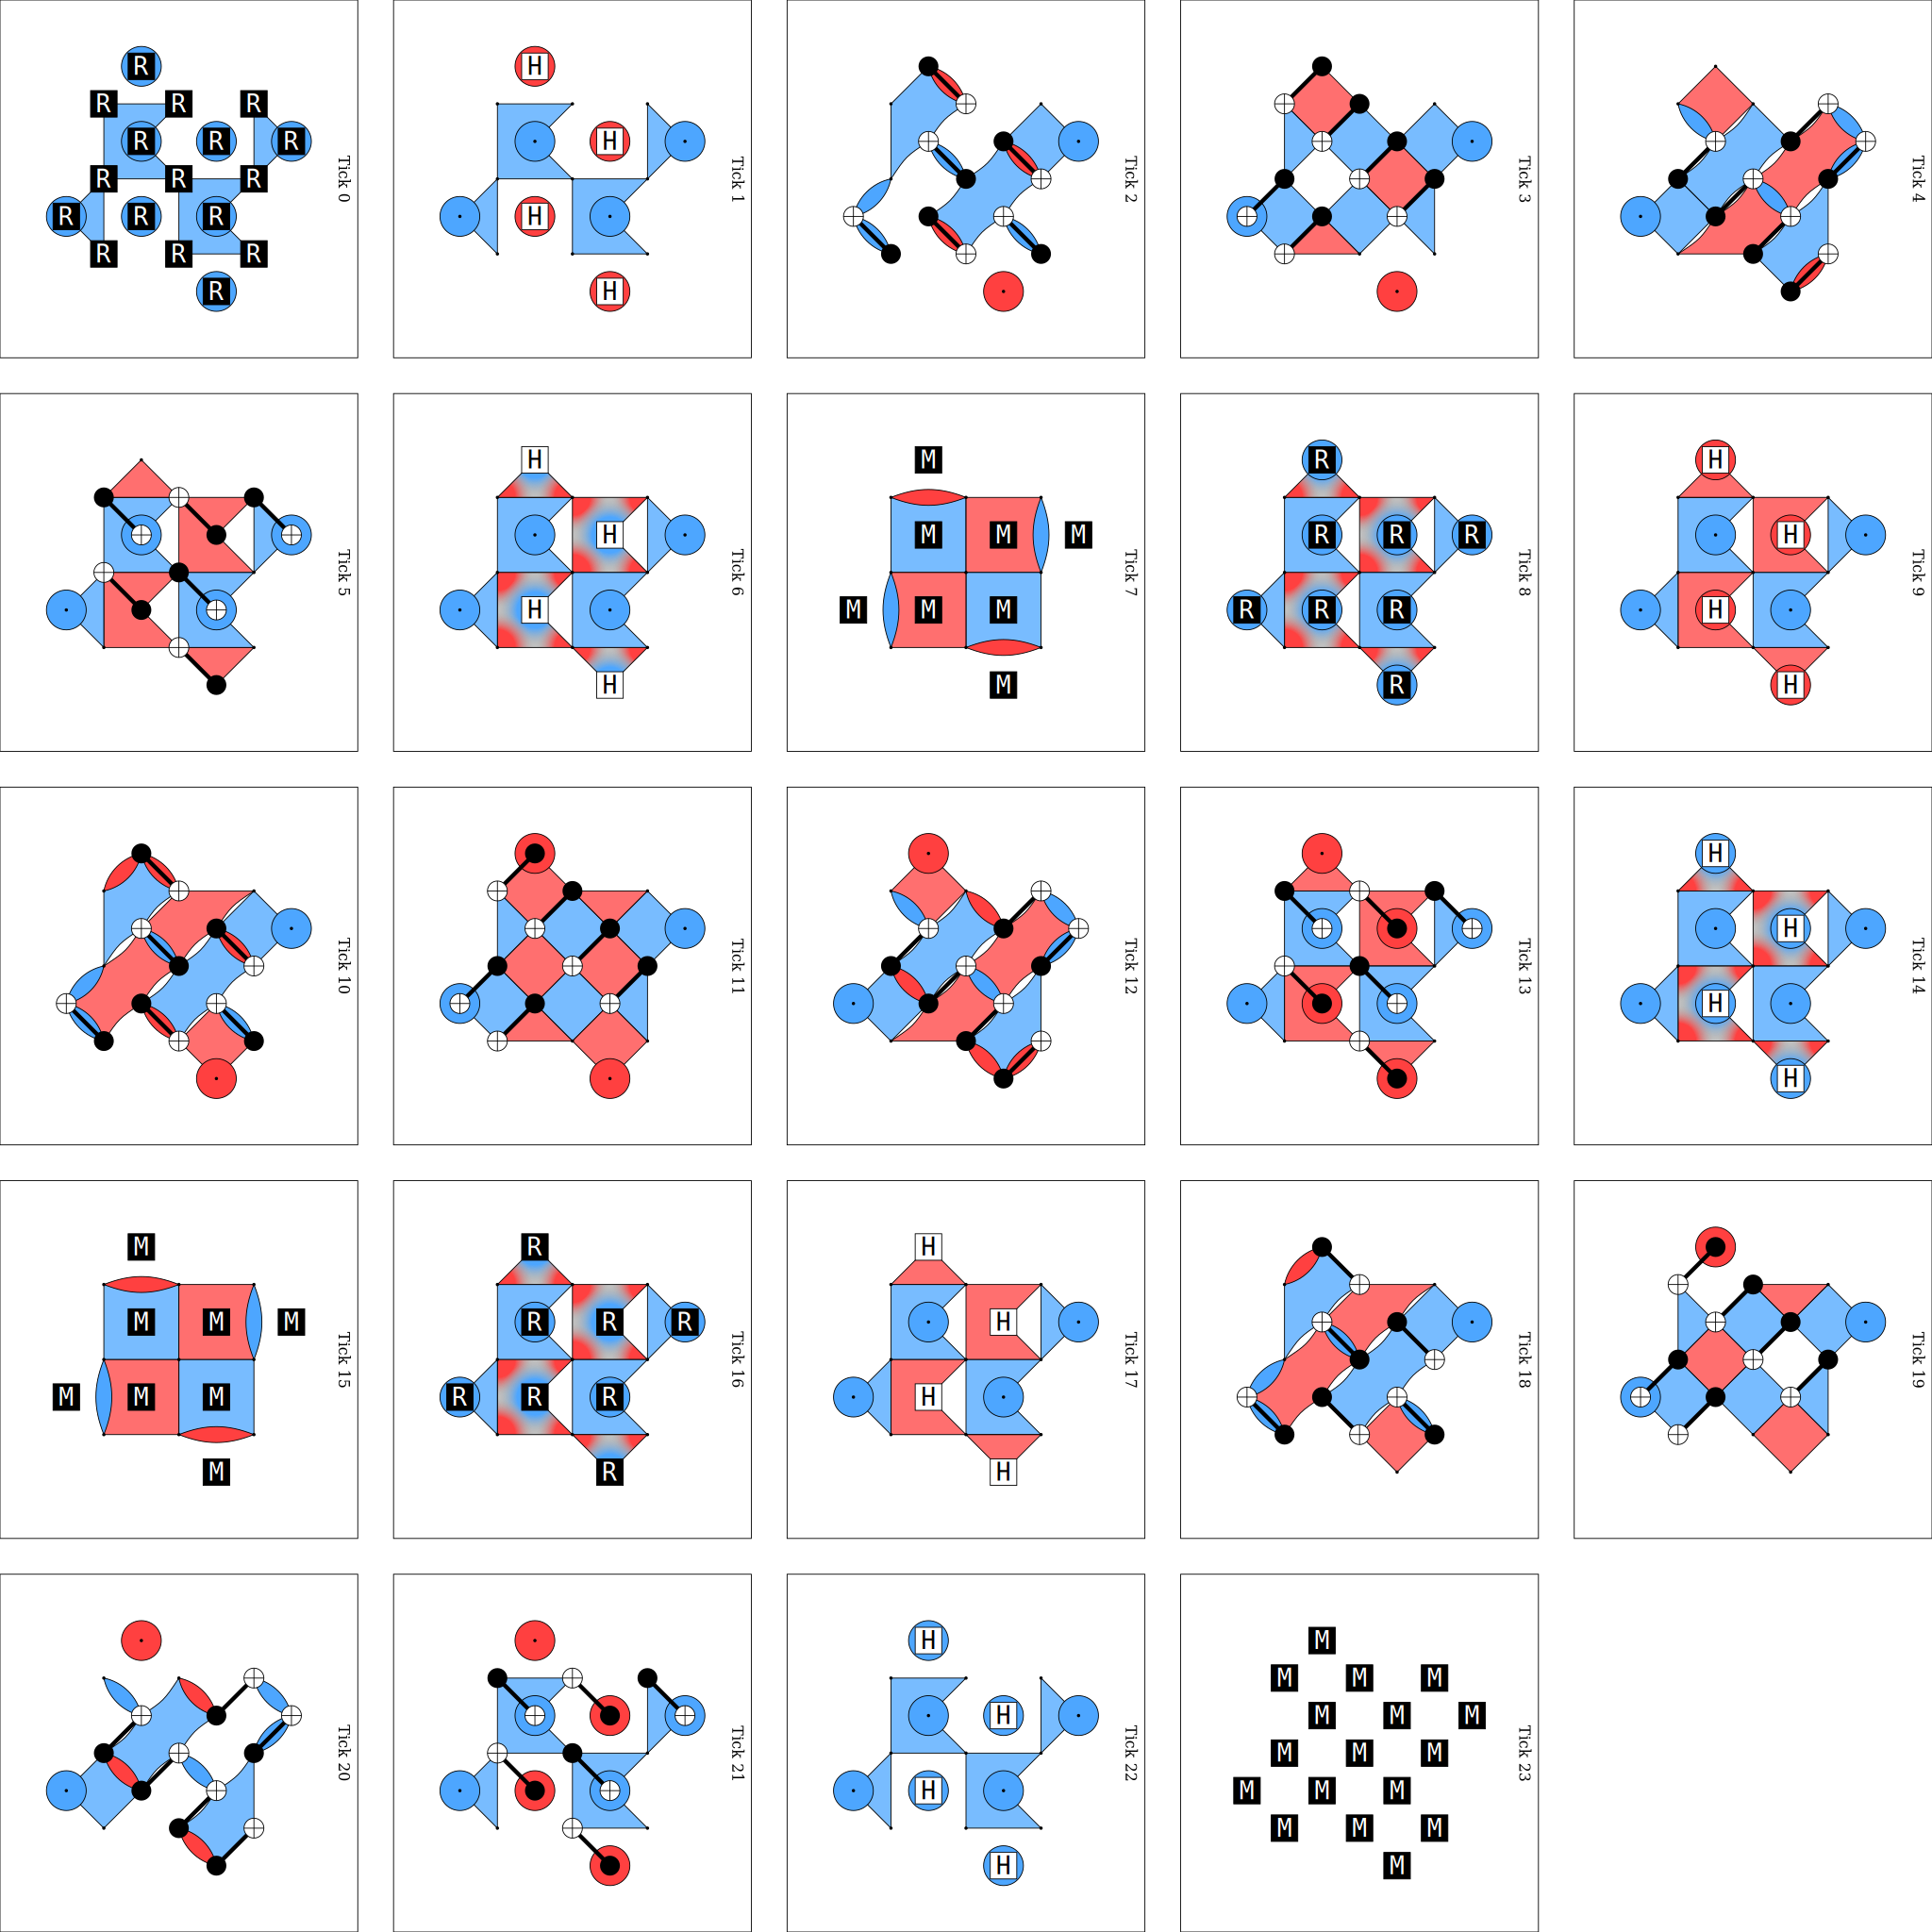

In [20]:
# Detector slice visualization (comment out if notebook becomes slow)
circuit_rotated.without_noise().diagram("detslice-with-ops-svg")
# circuit_rotated.without_noise().diagram("detslice-with-ops-svg", filter_coords=["L0"])

## 2. Unrotated Surface Code

In [21]:
d = 3
code = UnrotatedSurfaceCode(distance=d)
system = QECSystem()
system.add_patch(code, name="unrotated_sc")

exp = MemoryExperiment(
    qec_system=system,
    extraction_block_class=UnrotatedSurfaceCodeExtractionBlock,
    rounds=d,
    noise_params=noise_params,
    noise_model="circuit_level",
    basis="X", # Z or X
)
circuit_unrotated = exp.build()
print(f"Qubits: {circuit_unrotated.num_qubits}  Detectors: {circuit_unrotated.num_detectors}")

Qubits: 25  Detectors: 36


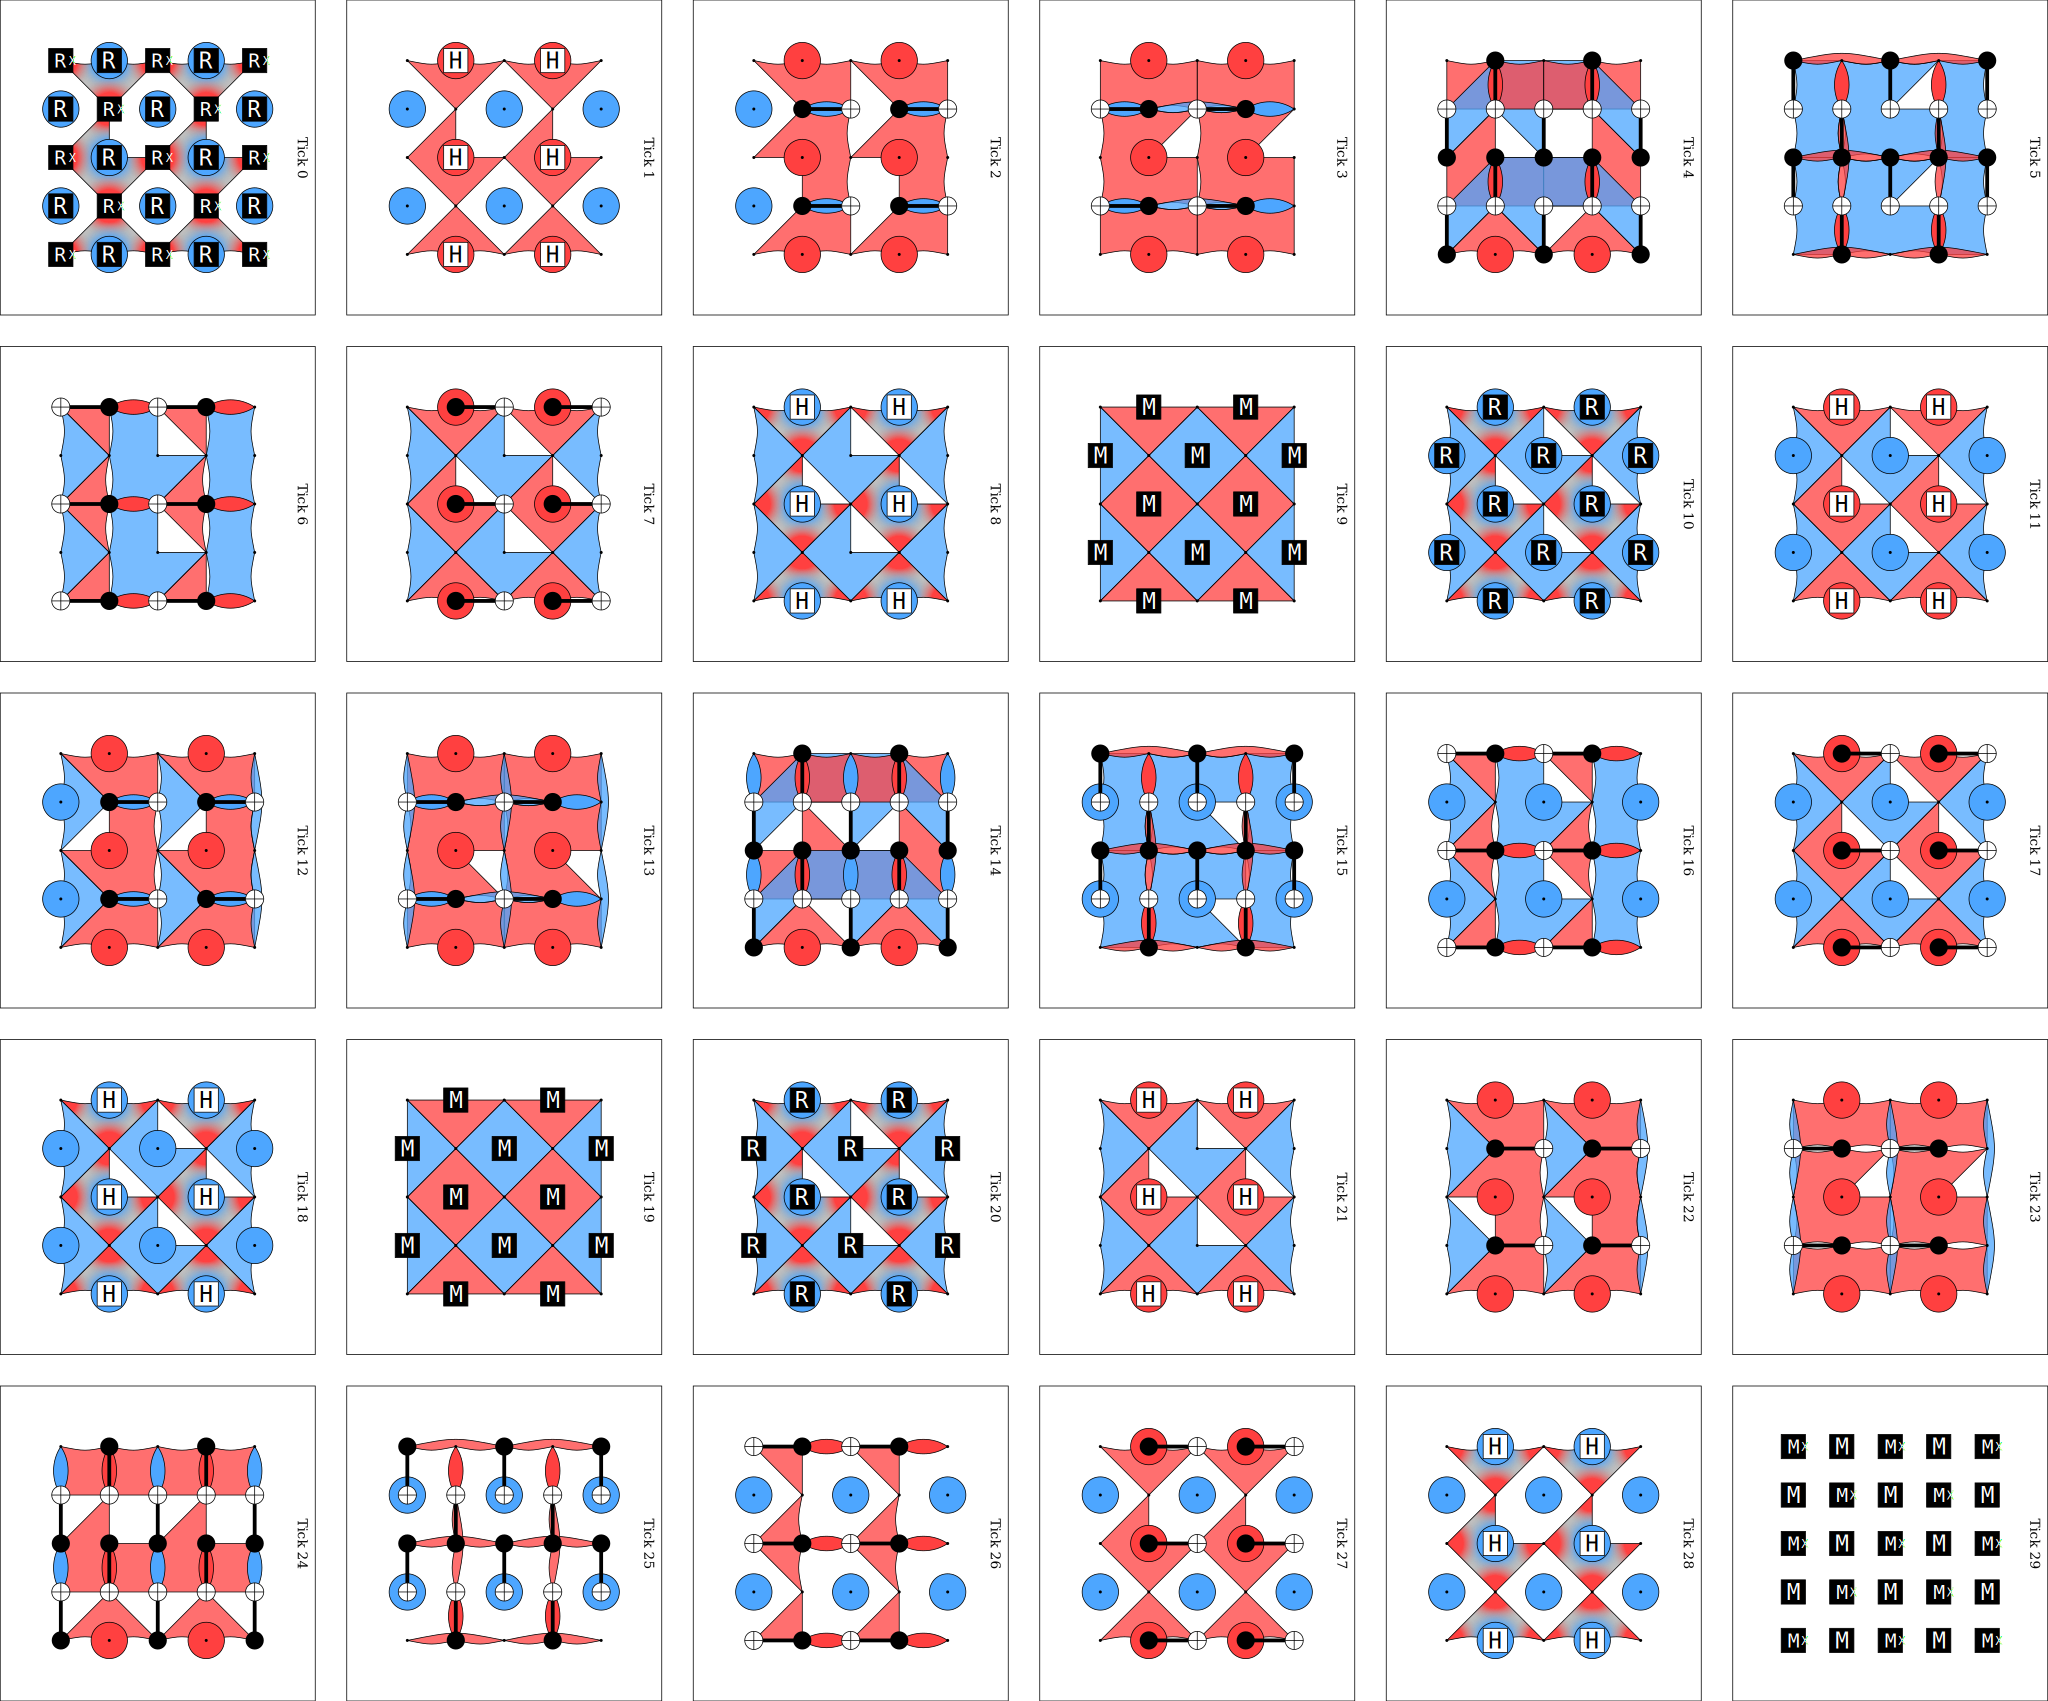

In [22]:
circuit_unrotated.without_noise().diagram("detslice-with-ops-svg")
# circuit_unrotated.without_noise().diagram("detslice-with-ops-svg", filter_coords=["L0"])

## 3. Toric Code

In [23]:
d = 3
code = ToricCode(distance=d)
system = QECSystem()
system.add_patch(code, name="toric")

exp = MemoryExperiment(
    qec_system=system,
    extraction_block_class=ToricCodeExtractionBlock,
    rounds=d,
    noise_params=noise_params,
    noise_model="circuit_level",
    basis="Z", # Z or X
)
circuit_toric = exp.build()
print(f"Qubits: {circuit_toric.num_qubits}  Detectors: {circuit_toric.num_detectors}")

Qubits: 36  Detectors: 56


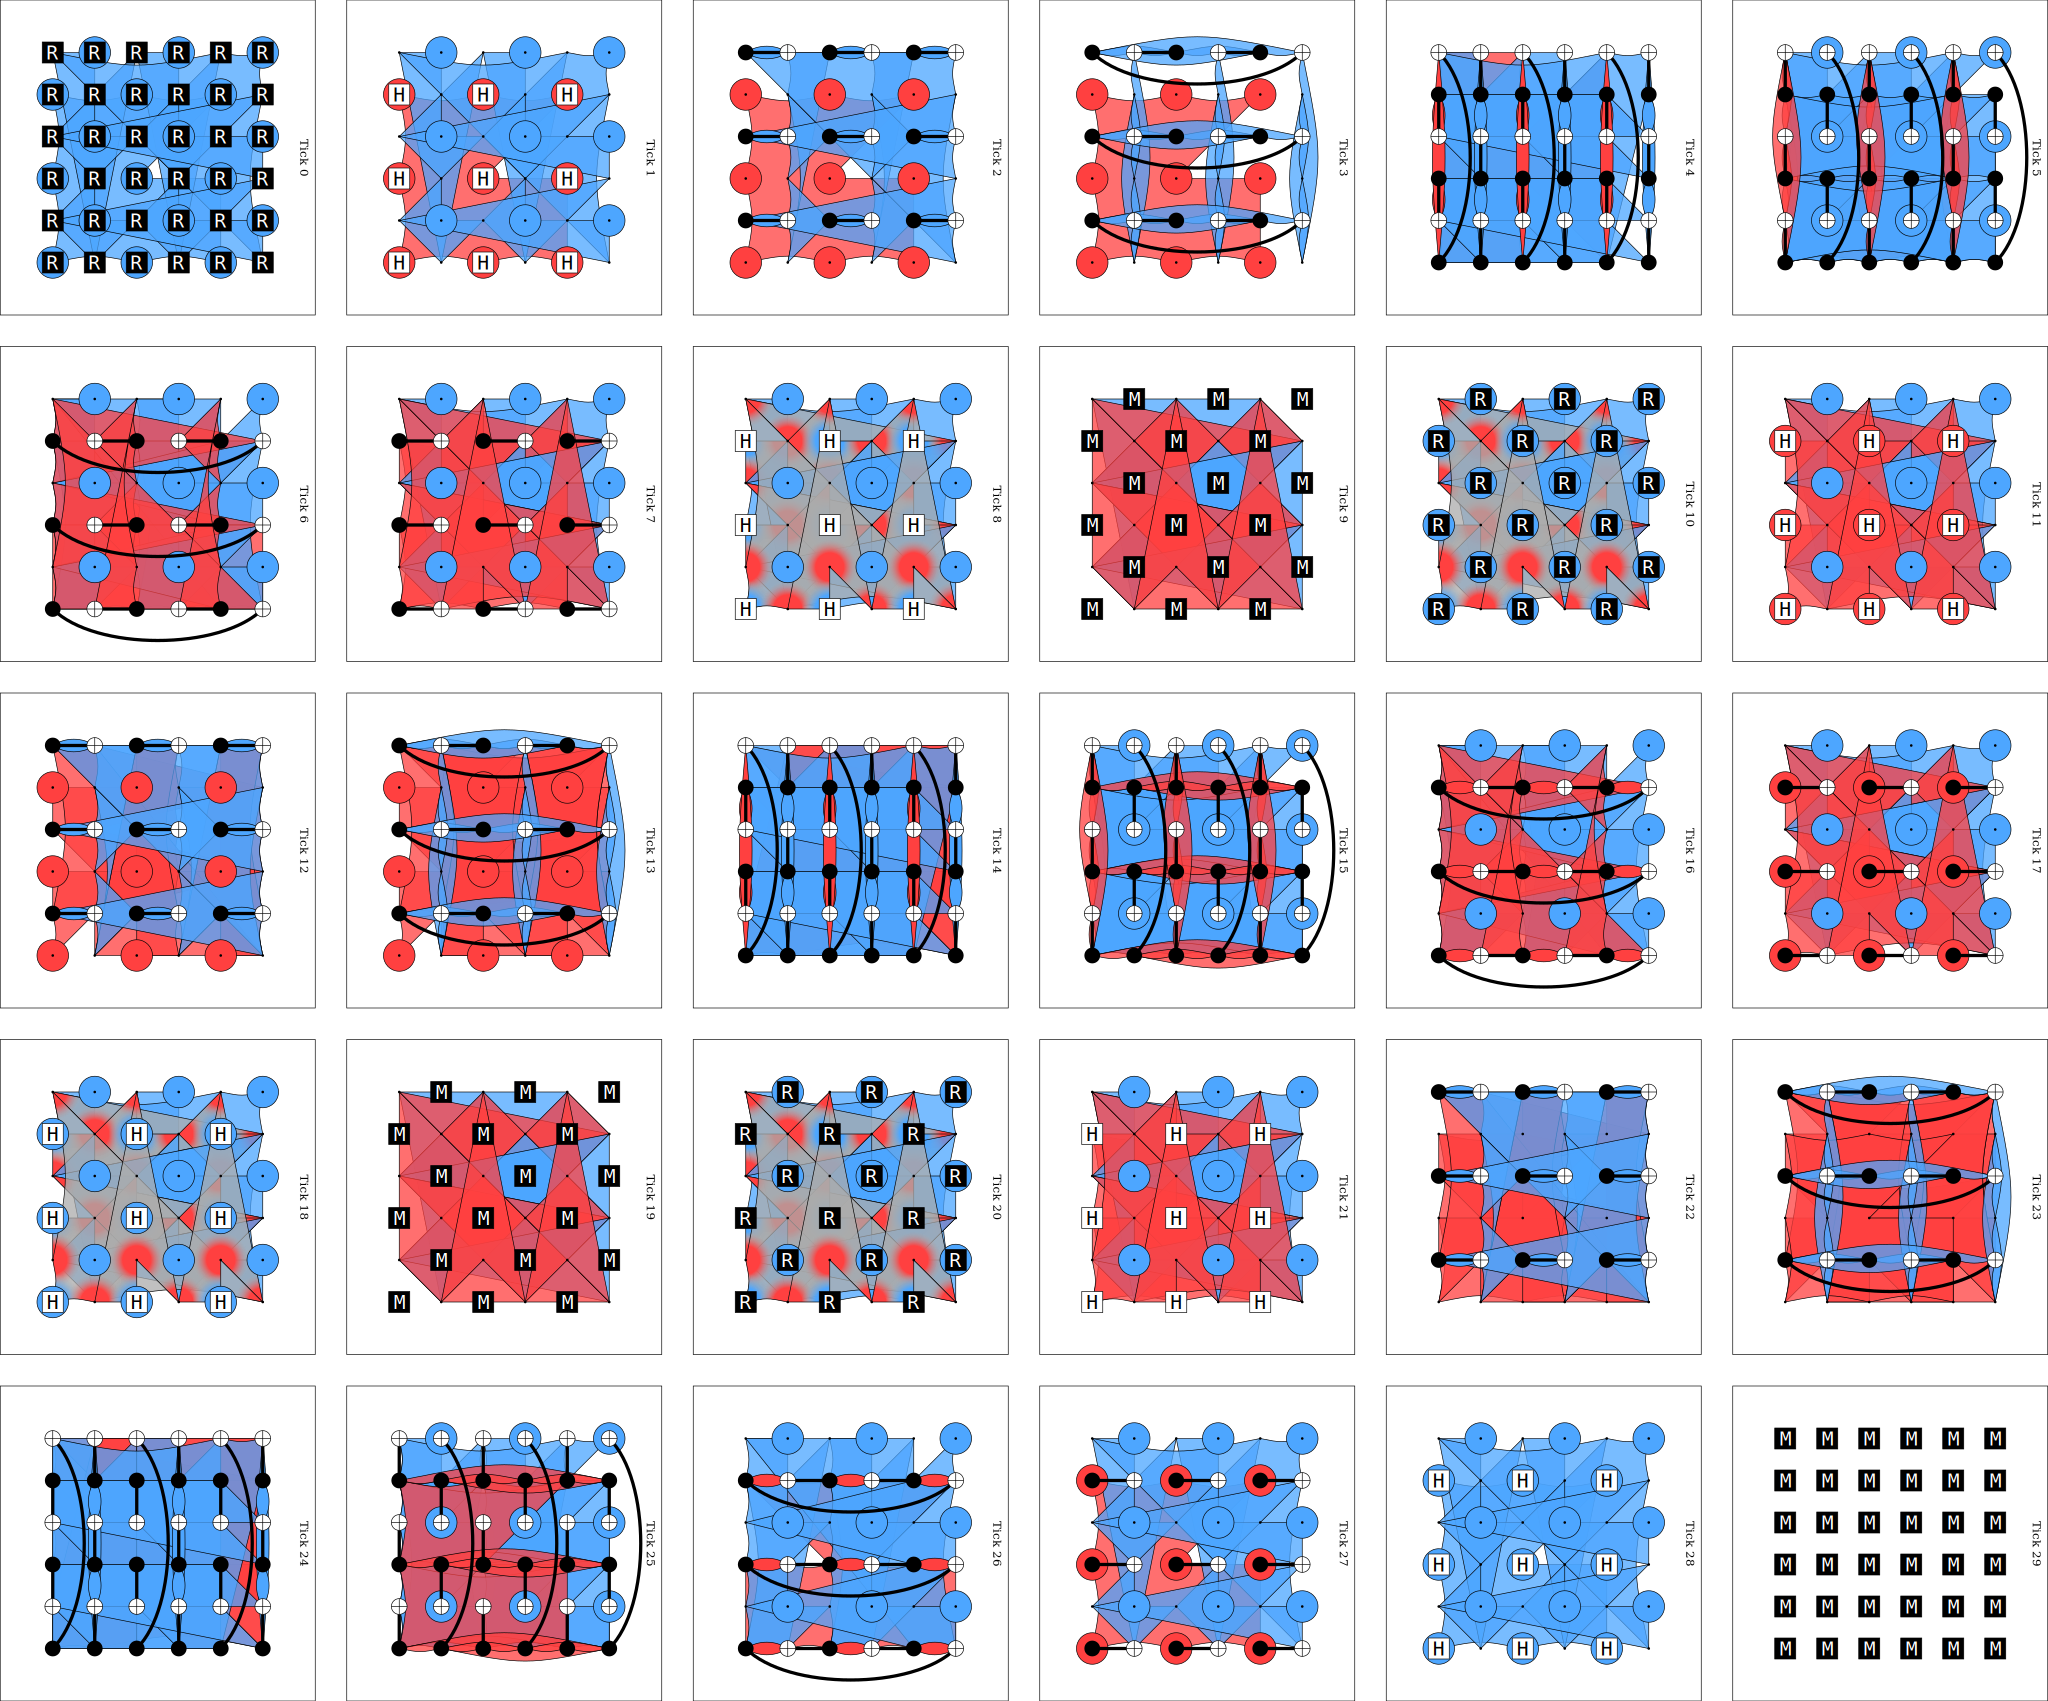

In [24]:
circuit_toric.without_noise().diagram("detslice-with-ops-svg")
# circuit_toric.without_noise().diagram("detslice-with-ops-svg", filter_coords=["L0"])